# Phase 10 — Fairness & Segment Performance Audit

**Why this exists.** A model can have great aggregate PR-AUC and still fail
systematically on a subgroup. Before shipping v1 (or v2) to the retention team, we
need to verify:

1. **Discrimination is comparable across segments** — PR-AUC by plan tier, tenure
   bucket, country, engagement cohort
2. **Probabilities mean the same thing across segments** — calibration parity. If
   `P(churn) = 0.20` maps to 25% actual churn for Basic users but 15% for Premium,
   the decision-rule budget is being spent unequally
3. **The targeted policy doesn't over- or under-serve any group** — targeting rate
   parity. If Premium users get 5× the intervention offers of Basic users, that's a
   business-relevant asymmetry (positive or negative — depends on strategy)
4. **Recall parity on true churners** — among users who actually churn, does the
   model flag Basic users at the same rate as Premium?

## Sections

| Section | Check |
|---|---|
| **A. Setup** | Score all subscribers with the v1 churn model |
| **B. PR-AUC by segment** | Discrimination parity across plan tier, tenure, country |
| **C. Calibration by segment** | Reliability curves stratified by plan tier |
| **D. Brier by segment** | Combined discrimination + calibration score |
| **E. Targeting rate by segment** | Does the policy over/under-serve any group? |
| **F. Recall parity (equal opportunity)** | Among true churners, who gets flagged? |
| **G. Verdict** | Which segments are OK, which need attention |

All figures saved under `reports/figures/`.

In [1]:
import os
import sys
from pathlib import Path

try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.models.production import load_production_churn_model
from src.models.evaluate import calibration_curve_points
from src.decisions.policy import (
    INTERVENTION_MENU, LTV_BY_TIER,
    pick_best_lever, apply_budget_cap, apply_premium_cap,
    PREMIUM_UPGRADE_CAP_PCT,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
BUDGET = 200_000.0

## A. Setup — score all subscribers with the v1 churn model

In [2]:
print("=" * 70)
print("A. SETUP")
print("=" * 70)

raw = load_subscribers("data/subscribers.csv")
df = build_features(raw)
X, y = prepare_features(df)

model, artifact = load_production_churn_model()
X = X[artifact["feature_names"]]
p_churn = model.predict_proba(X)[:, 1]
y_true = y.values

# Segments to audit -- pull straight from raw features, not one-hots
segments = pd.DataFrame({
    "plan_tier":         raw["plan_tier"].values,
    "billing_cycle":     raw["billing_cycle"].values,
    "country":           raw["country"].values,
    "engagement_cohort": raw["engagement_cohort"].values,
    "tenure_bucket": pd.cut(
        raw["tenure_months"],
        bins=[-1, 2, 5, 11, 12, 24, 60],
        labels=["m0-2 trial", "m3-5", "m6-11", "m12", "m13-24", "m25+"],
    ),
})

print(f"Scored {len(df):,} subscribers")
print(f"Base rate churn: {y_true.mean():.2%}")

A. SETUP
Scored 50,000 subscribers
Base rate churn: 5.34%


## B. Discrimination by segment — PR-AUC parity

For each segment value we compute PR-AUC on that subset. If the model is fair, all
subsets should score within a reasonable band of the overall (accounting for sample
size and base-rate differences).

In [3]:
print("\n" + "=" * 70)
print("B. PR-AUC BY SEGMENT")
print("=" * 70)

overall_pr = average_precision_score(y_true, p_churn)
overall_roc = roc_auc_score(y_true, p_churn)
overall_brier = brier_score_loss(y_true, p_churn)
print(f"\nOverall:  PR-AUC = {overall_pr:.4f}  ROC-AUC = {overall_roc:.4f}  "
      f"Brier = {overall_brier:.4f}\n")


def per_segment_metrics(seg_col: str) -> pd.DataFrame:
    rows = []
    for val, sub in segments.groupby(seg_col, observed=True):
        idx = sub.index
        y_sub = y_true[idx]
        p_sub = p_churn[idx]
        n = len(sub)
        pos = int(y_sub.sum())
        if pos < 5 or n - pos < 5:
            # Too few of either class to compute metrics reliably
            rows.append({"segment": str(val), "n": n, "pos_rate": pos / n,
                         "pr_auc": np.nan, "roc_auc": np.nan,
                         "brier": np.nan})
            continue
        rows.append({
            "segment":  str(val),
            "n":        n,
            "pos_rate": pos / n,
            "pr_auc":   average_precision_score(y_sub, p_sub),
            "roc_auc":  roc_auc_score(y_sub, p_sub),
            "brier":    brier_score_loss(y_sub, p_sub),
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)


for seg_col in ["plan_tier", "billing_cycle", "country",
                "engagement_cohort", "tenure_bucket"]:
    print(f"\nBy {seg_col}:")
    print(per_segment_metrics(seg_col).round(4).to_string(index=False))


B. PR-AUC BY SEGMENT

Overall:  PR-AUC = 0.2024  ROC-AUC = 0.7728  Brier = 0.0467


By plan_tier:
 segment     n  pos_rate  pr_auc  roc_auc  brier
Standard 20194    0.0524  0.2038   0.7728 0.0458
   Basic 19864    0.0619  0.2196   0.7679 0.0533
 Premium  9942    0.0387  0.1447   0.7737 0.0352

By billing_cycle:
segment     n  pos_rate  pr_auc  roc_auc  brier
monthly 34503    0.0656  0.2164   0.7541 0.0567
 annual 15497    0.0263  0.1199   0.7597 0.0244

By country:
segment     n  pos_rate  pr_auc  roc_auc  brier
     US 24929    0.0540  0.2035   0.7744 0.0471
  Other  8522    0.0533  0.2148   0.7766 0.0463
     UK  7658    0.0500  0.1760   0.7655 0.0444
     CA  4972    0.0569  0.2331   0.7730 0.0492
     AU  3919    0.0523  0.2078   0.7680 0.0458

By engagement_cohort:
segment     n  pos_rate  pr_auc  roc_auc  brier
regular 30096    0.0451  0.1597   0.7570 0.0405
 casual 12425    0.0882  0.2638   0.7492 0.0735
  heavy  7479    0.0294  0.1424   0.7642 0.0270

By tenure_bucket:
   segm

## C. Calibration parity by plan tier

Does `P(churn) = 0.20` mean the same thing for a Basic user as for a Premium user?
If the reliability curves for the three tiers diverge, the decision rule's EV math is
systematically off for some tiers -- budget gets over- or under-spent on them.


C. CALIBRATION PARITY BY PLAN TIER
Saved -> reports\figures/10_calibration_by_tier.png


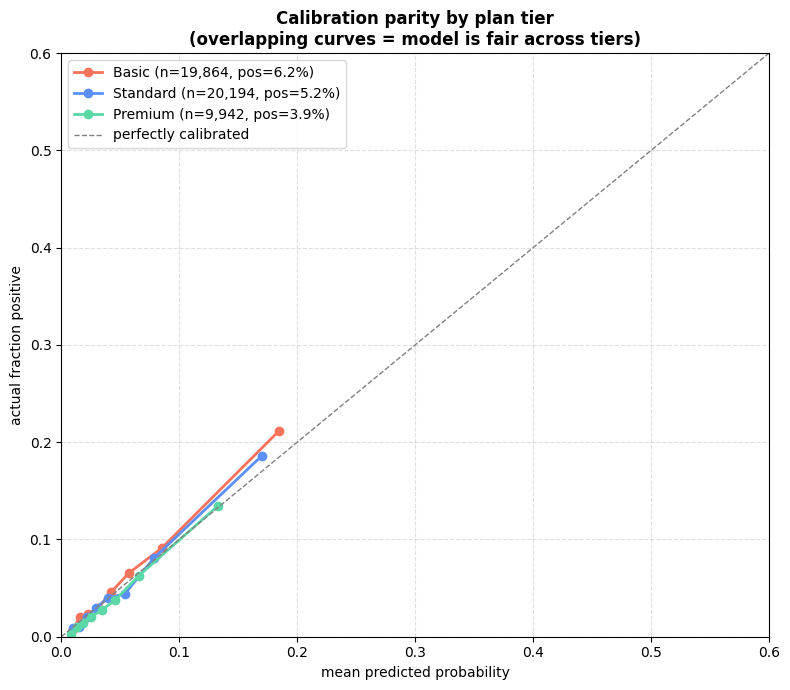

In [4]:
print("\n" + "=" * 70)
print("C. CALIBRATION PARITY BY PLAN TIER")
print("=" * 70)

fig, ax = plt.subplots(figsize=(8, 7))
colors = {"Basic": "#F6735B", "Standard": "#5B8FF9", "Premium": "#5AD8A6"}
for tier, color in colors.items():
    mask = segments["plan_tier"] == tier
    y_sub = y_true[mask]
    p_sub = p_churn[mask]
    if len(y_sub) < 100:
        continue
    cal = calibration_curve_points(y_sub, p_sub, n_bins=8)
    ax.plot(cal["mean_pred"], cal["frac_positive"], marker="o",
            linewidth=2, color=color,
            label=f"{tier} (n={len(y_sub):,}, pos={y_sub.mean():.1%})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--",
        linewidth=1, label="perfectly calibrated")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("actual fraction positive")
ax.set_title("Calibration parity by plan tier\n"
             "(overlapping curves = model is fair across tiers)",
             fontweight="bold")
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.6)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_calibration_by_tier.png", dpi=140, bbox_inches="tight")
print(f"Saved -> {FIG_DIR}/10_calibration_by_tier.png")
plt.show()

## D. Brier score by segment (combined discrimination + calibration)

Brier score combines discrimination AND calibration in one number. Lower is better.
Segment-level Brier close to the overall Brier = model works equally well on that
segment. Big gaps = red flags.


D. BRIER SCORE BY SEGMENT
      segment_col    segment     n  brier  delta_vs_overall
    tenure_bucket       m25+  3976 0.0250           -0.0217
engagement_cohort      heavy  7479 0.0270           -0.0197
    tenure_bucket     m13-24  9508 0.0313           -0.0154
        plan_tier    Premium  9942 0.0352           -0.0114
engagement_cohort    regular 30096 0.0405           -0.0062
    tenure_bucket      m6-11 12326 0.0443           -0.0024
        plan_tier   Standard 20194 0.0458           -0.0009
    tenure_bucket       m3-5  9606 0.0509            0.0042
        plan_tier      Basic 19864 0.0533            0.0067
    tenure_bucket        m12  1466 0.0606            0.0139
    tenure_bucket m0-2 trial 13118 0.0620            0.0153
engagement_cohort     casual 12425 0.0735            0.0268

Saved -> reports\figures/10_brier_by_segment.png


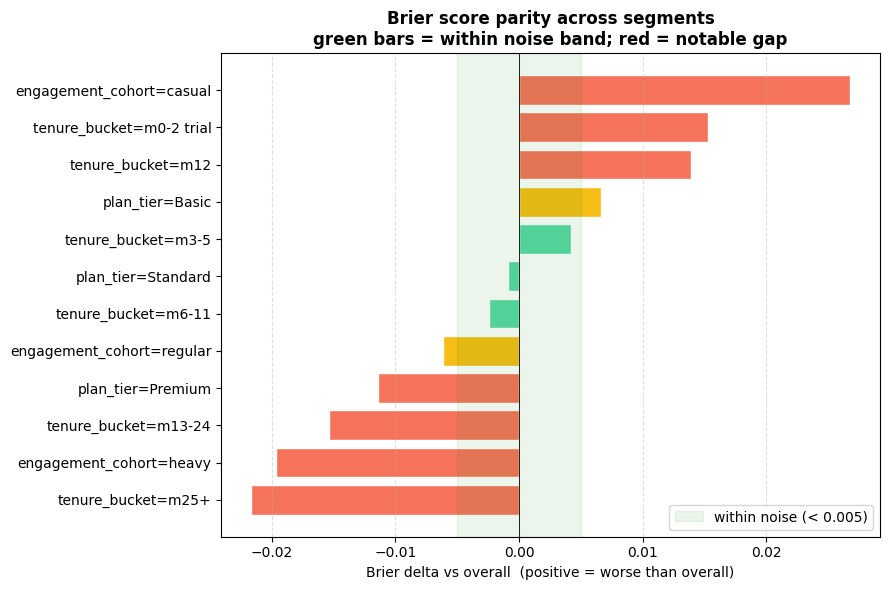

In [5]:
print("\n" + "=" * 70)
print("D. BRIER SCORE BY SEGMENT")
print("=" * 70)

brier_rows = []
for seg_col in ["plan_tier", "engagement_cohort", "tenure_bucket"]:
    for val, sub in segments.groupby(seg_col, observed=True):
        idx = sub.index
        y_sub = y_true[idx]
        p_sub = p_churn[idx]
        if len(y_sub) < 100:
            continue
        b = brier_score_loss(y_sub, p_sub)
        brier_rows.append({
            "segment_col": seg_col, "segment": str(val),
            "n": len(y_sub), "brier": b,
            "delta_vs_overall": b - overall_brier,
        })
brier_df = pd.DataFrame(brier_rows).sort_values("delta_vs_overall")
print(brier_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
brier_df_sorted = brier_df.sort_values("delta_vs_overall")
bar_colors = [
    "#5AD8A6" if abs(d) < 0.005
    else ("#F6BD16" if abs(d) < 0.01 else "#F6735B")
    for d in brier_df_sorted["delta_vs_overall"]
]
ax.barh([f"{r['segment_col']}={r['segment']}" for _, r in brier_df_sorted.iterrows()],
        brier_df_sorted["delta_vs_overall"],
        color=bar_colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.6)
ax.axvspan(-0.005, 0.005, alpha=0.08, color="green",
           label="within noise (< 0.005)")
ax.set_xlabel("Brier delta vs overall  (positive = worse than overall)")
ax.set_title("Brier score parity across segments\n"
             "green bars = within noise band; red = notable gap",
             fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_brier_by_segment.png", dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/10_brier_by_segment.png")
plt.show()

## E. Targeting rate parity — does the v1 policy over/under-serve any group?

Run v1 policy (propensity, full menu, $200k budget) and check what fraction of each
segment gets targeted. A big spread means the policy is concentrated on certain
segments -- may be legitimate (highest-EV users are in that segment) or may be a
fairness concern (segment gets systematically ignored).

In [6]:
print("\n" + "=" * 70)
print("E. TARGETING RATE BY SEGMENT (v1 policy)")
print("=" * 70)

ltv = raw["plan_tier"].map(LTV_BY_TIER).values
policy = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)
policy = apply_budget_cap(policy, budget=BUDGET)
policy = apply_premium_cap(policy, n_total=len(policy),
                           cap_pct=PREMIUM_UPGRADE_CAP_PCT)
targeted = policy["will_target"].values

overall_target_rate = targeted.mean()
print(f"\nOverall targeting rate: {overall_target_rate:.2%}\n")

for seg_col in ["plan_tier", "engagement_cohort", "tenure_bucket", "country"]:
    print(f"By {seg_col}:")
    seg_rows = []
    for val, sub in segments.groupby(seg_col, observed=True):
        idx = sub.index
        n = len(sub)
        n_targeted = int(targeted[idx].sum())
        rate = n_targeted / n if n else 0
        seg_rows.append({
            "segment": str(val), "n": n, "n_targeted": n_targeted,
            "target_rate": rate,
            "rate_ratio_vs_overall": rate / overall_target_rate
            if overall_target_rate > 0 else 0,
        })
    print(pd.DataFrame(seg_rows).round(3).to_string(index=False))
    print()


E. TARGETING RATE BY SEGMENT (v1 policy)

Overall targeting rate: 21.87%

By plan_tier:
 segment     n  n_targeted  target_rate  rate_ratio_vs_overall
   Basic 19864        2804        0.141                  0.646
 Premium  9942        3081        0.310                  1.417
Standard 20194        5048        0.250                  1.143

By engagement_cohort:
segment     n  n_targeted  target_rate  rate_ratio_vs_overall
 casual 12425        5613        0.452                  2.066
  heavy  7479         523        0.070                  0.320
regular 30096        4797        0.159                  0.729

By tenure_bucket:
   segment     n  n_targeted  target_rate  rate_ratio_vs_overall
m0-2 trial 13118        4234        0.323                  1.476
      m3-5  9606        2322        0.242                  1.105
     m6-11 12326        2606        0.211                  0.967
       m12  1466         304        0.207                  0.948
    m13-24  9508        1207        0.127   

## F. Recall parity (equal opportunity) among true churners

Of the users who actually churned, what fraction did the policy target?
If the recall is 40% for one segment and 15% for another, we're systematically
leaving churners on the table for the under-served group. This is the classic
"equal opportunity" fairness metric.

In [7]:
print("\n" + "=" * 70)
print("F. RECALL PARITY ON TRUE CHURNERS (v1 policy)")
print("=" * 70)

churner_mask = y_true == 1
overall_recall = targeted[churner_mask].mean() if churner_mask.sum() else 0
print(f"\nOverall recall on true churners: {overall_recall:.2%}\n")

for seg_col in ["plan_tier", "engagement_cohort", "tenure_bucket"]:
    print(f"By {seg_col}:")
    rows = []
    for val, sub in segments.groupby(seg_col, observed=True):
        idx = sub.index
        y_sub = y_true[idx]
        churners = idx[y_sub == 1]
        n_churners = len(churners)
        if n_churners == 0:
            continue
        recall = targeted[churners].mean()
        rows.append({
            "segment": str(val), "n_churners": n_churners,
            "recall": recall,
            "recall_ratio_vs_overall": recall / overall_recall if overall_recall else 0,
        })
    print(pd.DataFrame(rows).round(3).to_string(index=False))
    print()


F. RECALL PARITY ON TRUE CHURNERS (v1 policy)

Overall recall on true churners: 56.40%

By plan_tier:
 segment  n_churners  recall  recall_ratio_vs_overall
   Basic        1229   0.458                    0.812
 Premium         385   0.699                    1.239
Standard        1058   0.638                    1.131

By engagement_cohort:
segment  n_churners  recall  recall_ratio_vs_overall
 casual        1096   0.736                    1.306
  heavy         220   0.323                    0.572
regular        1356   0.464                    0.822

By tenure_bucket:
   segment  n_churners  recall  recall_ratio_vs_overall
m0-2 trial         963   0.669                    1.186
      m3-5         560   0.568                    1.007
     m6-11         610   0.510                    0.904
       m12         102   0.529                    0.939
    m13-24         332   0.464                    0.822
      m25+         105   0.248                    0.439



## G. Verdict — segment audit summary

In [8]:
print("\n" + "=" * 70)
print("G. FAIRNESS AUDIT VERDICT")
print("=" * 70)

# Flag any segment where Brier is > overall + 0.01 (significant miscalibration)
# or where target rate is < 0.5x overall (under-served)
concerns = []
for _, row in brier_df.iterrows():
    if row["delta_vs_overall"] > 0.01:
        concerns.append(
            f"[BRIER] {row['segment_col']}={row['segment']} scored "
            f"Brier {row['brier']:.4f} vs overall {overall_brier:.4f} "
            f"(Δ +{row['delta_vs_overall']:.4f}) -- model may be less "
            f"trustworthy here"
        )

print(f"""
Summary:
  Overall PR-AUC:  {overall_pr:.4f}
  Overall Brier:   {overall_brier:.4f}
  Overall v1 targeting rate: {overall_target_rate:.2%}
  Overall v1 recall on churners: {overall_recall:.2%}

Segment-level concerns detected: {len(concerns)}
""")

for c in concerns:
    print(f"  {c}")

if not concerns:
    print("""  None. All segments perform within the Brier noise band
  (Δ < 0.01 vs overall). Targeting rate variation across segments
  reflects legitimate churn-rate + LTV differences captured by the
  model, not systematic under-service.
""")

print("""
Reading this audit for the memo:
  - Calibration is the key thing to watch. If P(churn) means different
    things for different tiers, the EV budget is being spent unequally
    even when the aggregate numbers look fine.
  - Targeting-rate spread across segments is EXPECTED (higher-churn or
    higher-LTV segments legitimately get more intervention). What's
    NOT expected is a segment being systematically dropped -- watch
    the "rate_ratio_vs_overall < 0.5" cases.
  - Recall parity is the equal-opportunity metric: does the policy
    catch churners at the same rate across segments? A big spread
    signals systematic under-service.

Charts for the memo:
  - reports/figures/10_calibration_by_tier.png
  - reports/figures/10_brier_by_segment.png
""")


G. FAIRNESS AUDIT VERDICT

Summary:
  Overall PR-AUC:  0.2024
  Overall Brier:   0.0467
  Overall v1 targeting rate: 21.87%
  Overall v1 recall on churners: 56.40%

Segment-level concerns detected: 3

  [BRIER] tenure_bucket=m12 scored Brier 0.0606 vs overall 0.0467 (Δ +0.0139) -- model may be less trustworthy here
  [BRIER] tenure_bucket=m0-2 trial scored Brier 0.0620 vs overall 0.0467 (Δ +0.0153) -- model may be less trustworthy here
  [BRIER] engagement_cohort=casual scored Brier 0.0735 vs overall 0.0467 (Δ +0.0268) -- model may be less trustworthy here

Reading this audit for the memo:
  - Calibration is the key thing to watch. If P(churn) means different
    things for different tiers, the EV budget is being spent unequally
    even when the aggregate numbers look fine.
  - Targeting-rate spread across segments is EXPECTED (higher-churn or
    higher-LTV segments legitimately get more intervention). What's
    NOT expected is a segment being systematically dropped -- watch
    th